Netflix Data Analysis

This project analyzes Netflix content to uncover trends in:
- Content growth over time
- Movies vs TV Shows
- Country-wise distribution
- Top directors

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

Firsty we will import the dataset into a pandas dataframe.

In [3]:
df = pd.read_csv("netflix_titles.csv")

Now let's see what columns do we have.

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Now looking at the topmost structure of the dataframe.

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Now looking at the bottommost structure of the dataset

In [6]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


Let's see how many values are there in each column.

In [7]:
df.count()

show_id         8807
type            8807
title           8807
director        6173
cast            7982
country         7976
date_added      8797
release_year    8807
rating          8803
duration        8804
listed_in       8807
description     8807
dtype: int64

Now looking at the datatypes

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Let's see how many null values do we got in each column.

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

For the null values in 'director','cast','country','rating','duration' columns we will fill them with formalities like 'unknown','not rated' etc.
But as the column 'date_added' is crucial for further analysis we will drop all the rows in which its value is null.

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df.dropna(subset = ['date_added'],inplace=True)
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

Once again checking all the null values

In [11]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Now we will convert the 'date_added' column from string datatype to datetime datatype

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed')

Now we will extract year addeed and month added into separate columns for further analysis

In [13]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

Now we will split the 'listed_in' column and form a new dataframe including all the separate values for different genres.

In [14]:
df['listed_in'] = df['listed_in'].str.split(',')
df_genre = df.explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

Now we will perform visualisations to extract key insights from the data

In [15]:
df['year_added'].value_counts()

year_added
2019    2016
2020    1879
2018    1649
2021    1498
2017    1188
2016     429
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

In [16]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [17]:
data = df.groupby(['year_added', 'type']).size().unstack()

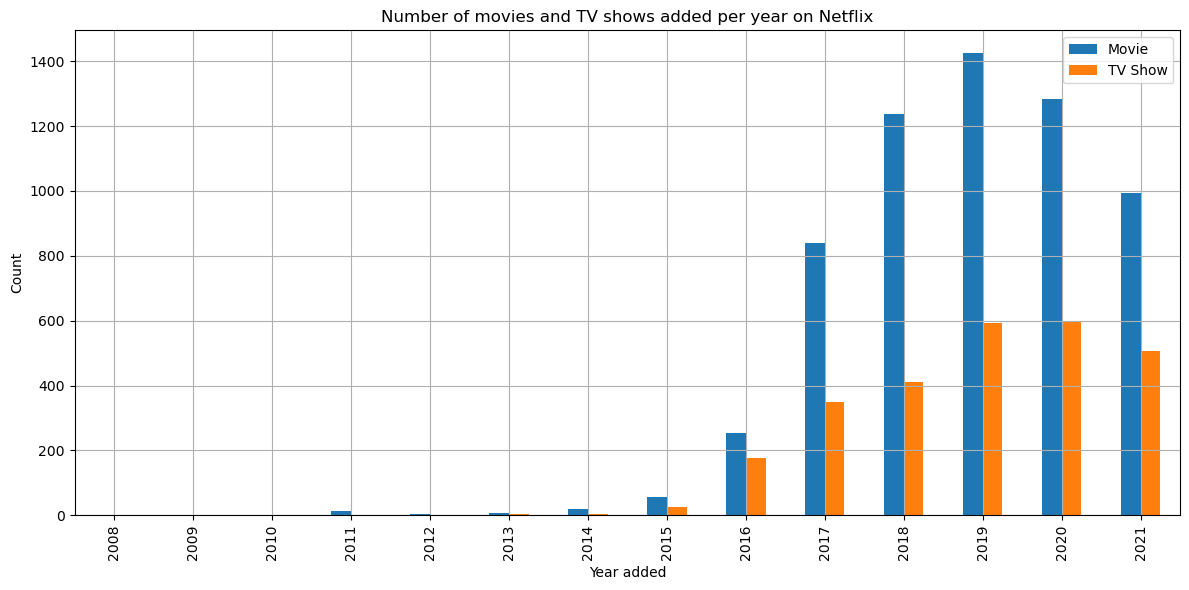

In [18]:
data.plot(kind = "bar",figsize = (12,6))
plt.xlabel("Year added")
plt.ylabel("Count")
plt.title("Number of movies and TV shows added per year on Netflix")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In the above graph we can clearly see that movies were added almost 3 times more than the TV shows on netflix(Movies=6131,TV Show=2666).it means people prefer to watch movies more than TV shows in general. But as the years passed TV shows were added more than their previous amount and movies were added less. This shows that over time the attention span of the people was declined and they are slowly shifting toward TV shows..
Moreover maximum content was added in year 2019 and the amount of content added is increasing at a slow rate.

In [19]:
df['country'].value_counts()

country
United States                                             2812
India                                                      972
Unknown                                                    830
United Kingdom                                             418
Japan                                                      244
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64

In [20]:
data2 = df.query("country=='India' or country=='United States'")

In [21]:
data2 = data2.groupby(['year_added','country']).size().unstack()

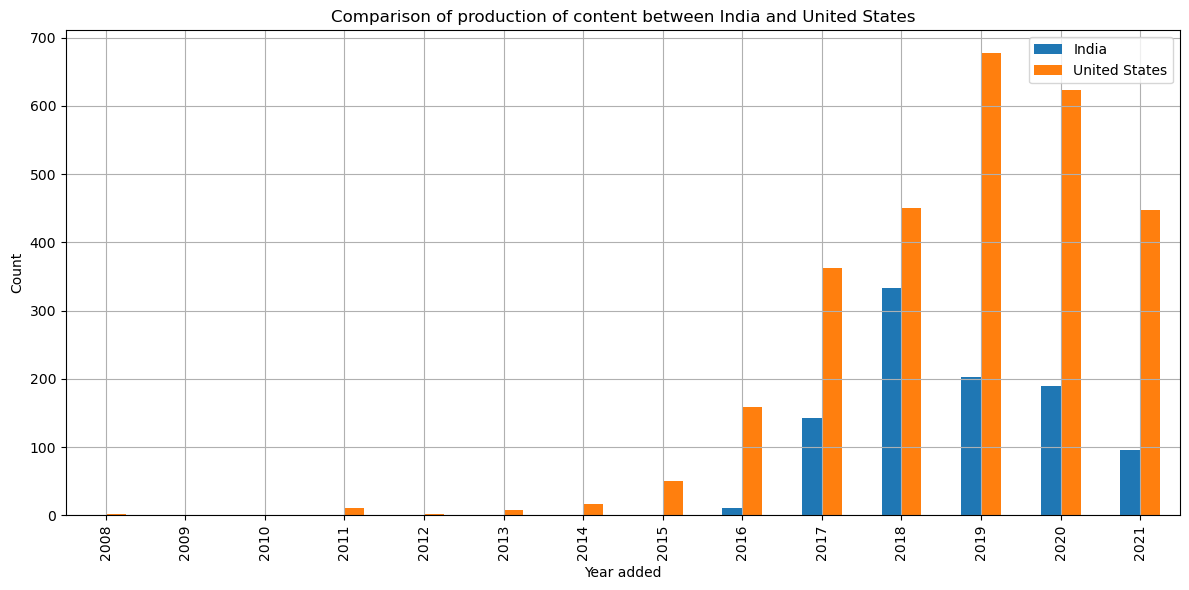

In [22]:
data2.plot(kind = "bar",figsize = (12,6))
plt.xlabel("Year added")
plt.ylabel("Count")
plt.title("Comparison of production of content between India and United States")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

Earlier India was not much into content creation but overtime it started reaching the heights becoming the country with the most produced content after the United States. In year 2018 India prodcued the maximum content almost touching the US levels. Soon it is expected for india to overtake US if it keeps growing at this pace.

United States produced 2812 movies whereas
India produced 972 movies.

In [23]:
data_3 = df.query("type=='TV Show'")

In [24]:
data3 = data_3['rating'].value_counts().sort_index()
data3

rating
NR              4
Not Rated       2
R               2
TV-14         730
TV-G           94
TV-MA        1143
TV-PG         321
TV-Y          175
TV-Y7         194
TV-Y7-FV        1
Name: count, dtype: int64

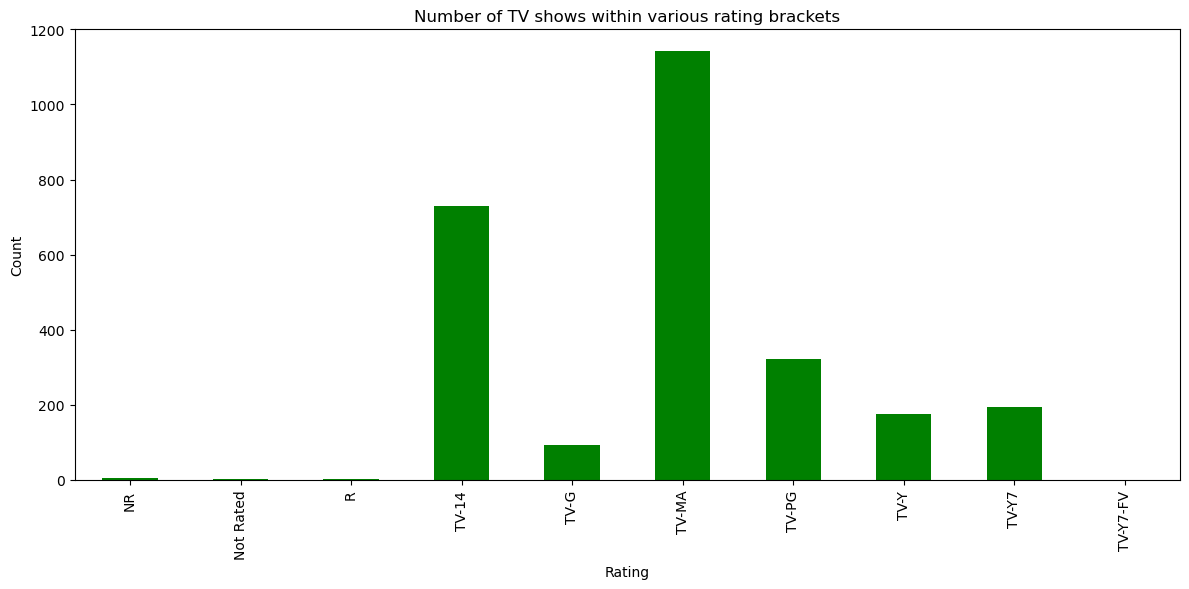

In [25]:
data3.plot(kind = "bar",figsize = (12,6), color ="green")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Number of TV shows within various rating brackets")
plt.tight_layout()
plt.show()

Maximum TV shows were within the rating brackets of TV-MA and TV-14 (TV-MA=1143 and TV-14=730). It show that most of the audience on netflix are adults and teenagers. They are the masses of netflix and maximum content is added keeping the preference of this age range.

In [26]:
data4 = data_3['duration'].value_counts()[:8]
data4 = pd.DataFrame(data4)
data4 = data4.sort_values('duration')
data4

,count
duration,
1 Season,1793
2 Seasons,421
3 Seasons,198
4 Seasons,94
5 Seasons,64
6 Seasons,33
7 Seasons,23
8 Seasons,17


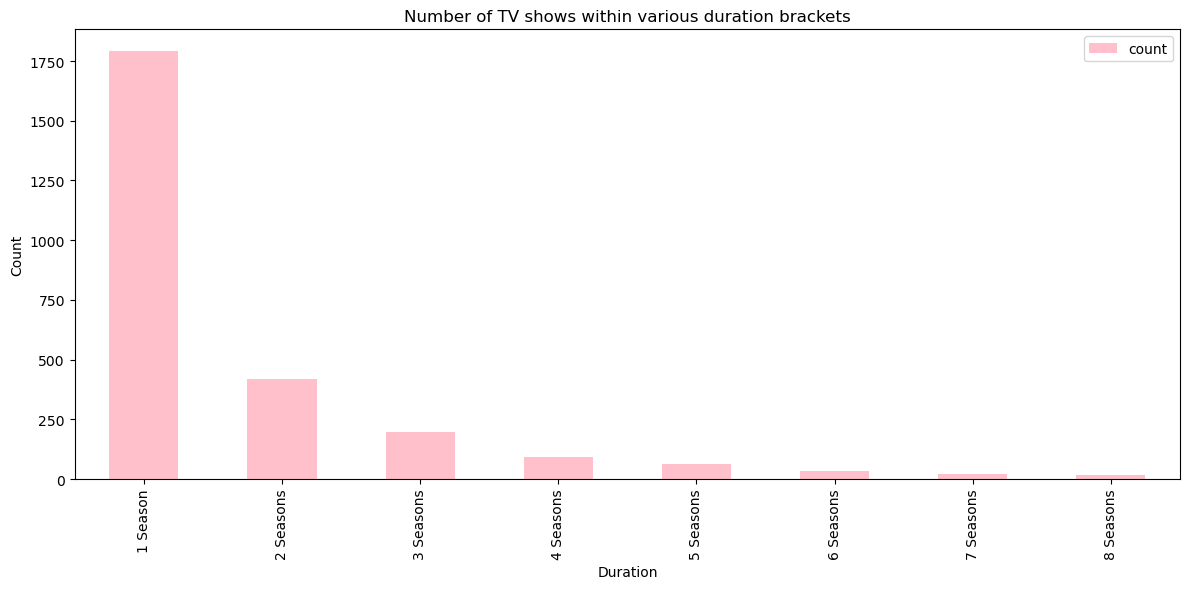

In [27]:
data4.plot(kind = "bar",figsize = (12,6),color = "pink")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.title("Number of TV shows within various duration brackets")
plt.tight_layout()
plt.show()

Maximum number of TV shows on netflix are very short in duration.There is a downward trend in number of shows as the number of season increases. This shows that people don't prefer to watch long duration of TV shows. Maximum number of TV shows are only of 1 season and shows consisting of 2 seasons are at second place.
(1 Season=1793 and
2 Seasons=421)

In [28]:
data_5 = df.query("type=='Movie'")

In [29]:
data5 = data_5['rating'].value_counts().sort_index()
data5

rating
66 min          1
74 min          1
84 min          1
G              41
NC-17           3
NR             75
Not Rated       2
PG            287
PG-13         490
R             797
TV-14        1427
TV-G          126
TV-MA        2062
TV-PG         540
TV-Y          131
TV-Y7         139
TV-Y7-FV        5
UR              3
Name: count, dtype: int64

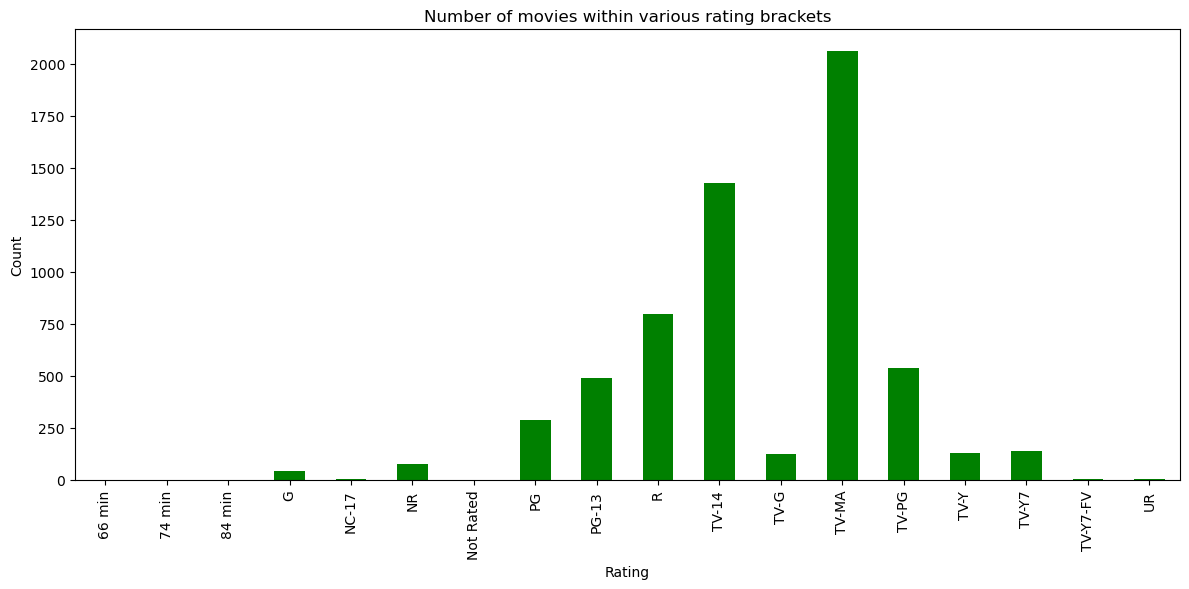

In [30]:
data5.plot(kind = "bar",figsize = (12,6),color =  "green")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Number of movies within various rating brackets")
plt.tight_layout()
plt.show()

Again as same as the TV shows maximum number of movies are of TV-MA and TV-14 rating. It shows there is mnore content for teenagers and adult on netflix
(TV-MA=2062 and TV-14=1427)

In [31]:
data6 = data_5['duration'].value_counts()[0:40]
data6 = pd.DataFrame(data6)
data6 = data6.sort_values('duration')
data6

,count
duration,
100 min,108
101 min,116
102 min,122
103 min,114
104 min,104
105 min,101
106 min,111
107 min,98
108 min,87


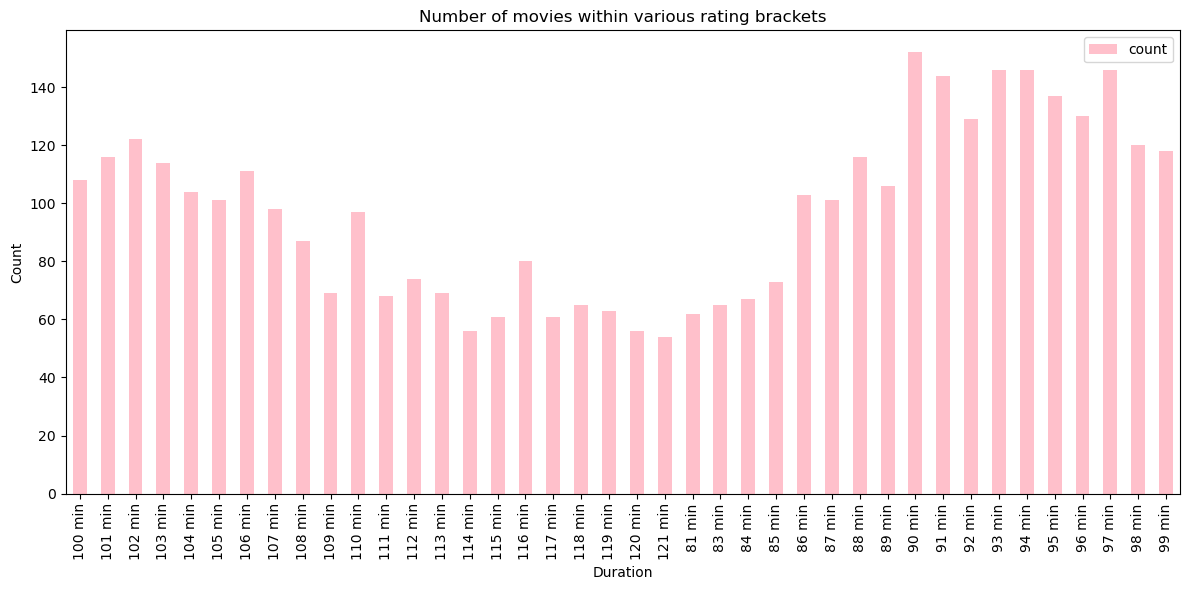

In [32]:
data6.plot(kind = "bar",figsize = (12,6),color = "pink")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.title("Number of movies within various rating brackets")
plt.tight_layout()
plt.show()

Maximum number of movies on netflix are generally of short duration. Movies of length around 90 minutes are preffered more.This strongly suggests that the attention span of the people is declining over time.
(88 min=116,
89 min=106,
90 min=152,
91 min=144,
92 min=129 and
93 min=146)

In [33]:
data7 = df['director'].value_counts()[1:6]
data7

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64

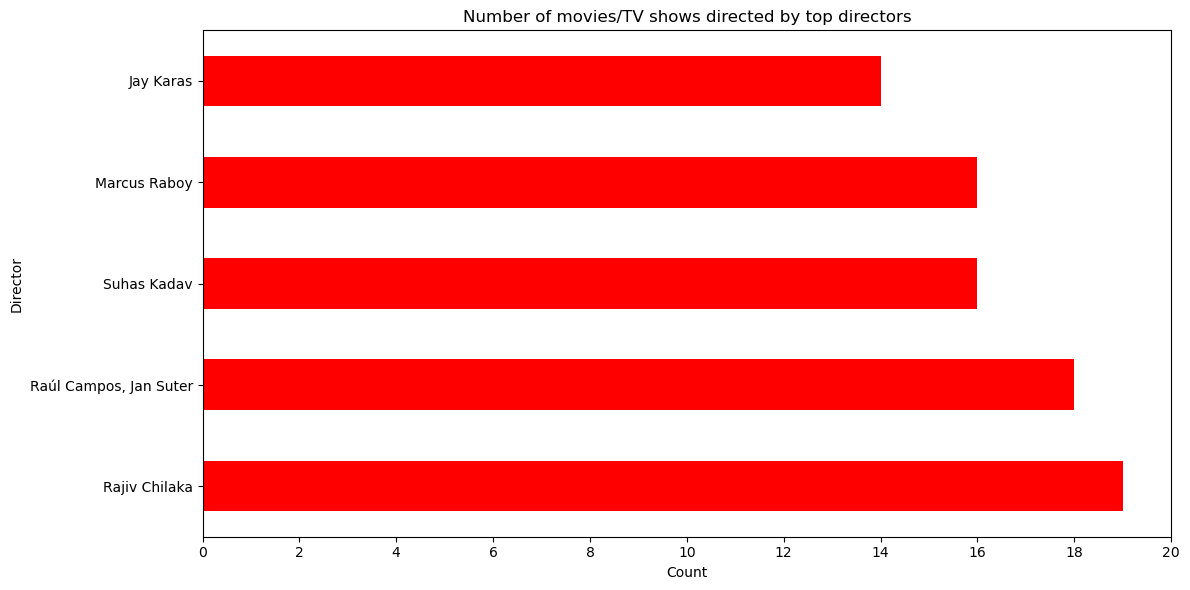

In [34]:
data7.plot(kind = "barh",figsize = (12,6),color = "red")
plt.ylabel("Director")
plt.xlabel("Count")
plt.title("Number of movies/TV shows directed by top directors")
plt.xticks(range(0, 21, 2))
plt.tight_layout()
plt.show()

Maximum number of movies/TV shows available on netflix were directed by Rajiv chilaka and Raúl Campos and Jan Suter at the second.
(Rajiv Chilaka=19,
Raúl Campos, Jan Suter=18,
Suhas Kadav=16,
Marcus Raboy=16 and
Jay Karas=14)

In [35]:
data8 = df['month_added'].value_counts().sort_index()
data8

month_added
1     738
2     563
3     742
4     764
5     632
6     728
7     827
8     755
9     770
10    760
11    705
12    813
Name: count, dtype: int64

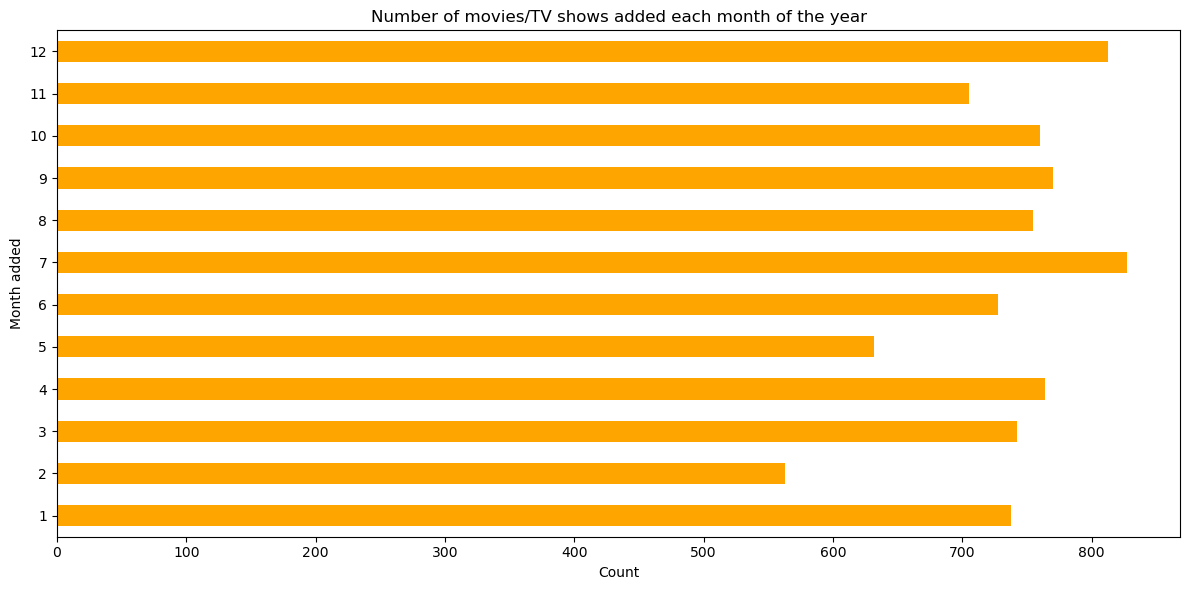

In [36]:
data8.plot(kind = "barh",figsize = (12,6),color = "orange")
plt.ylabel("Month added")
plt.xlabel("Count")
plt.title("Number of movies/TV shows added each month of the year")
plt.tight_layout()
plt.show()

Content was added almost equally over each month on netflix but maximum content was added in the month of july and december.
(July=827 and December=813)

In [37]:
data9 = df['release_year'].value_counts().sort_index()[-22:]
data9

release_year
2000      37
2001      45
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     193
2011     185
2012     236
2013     287
2014     352
2015     558
2016     901
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

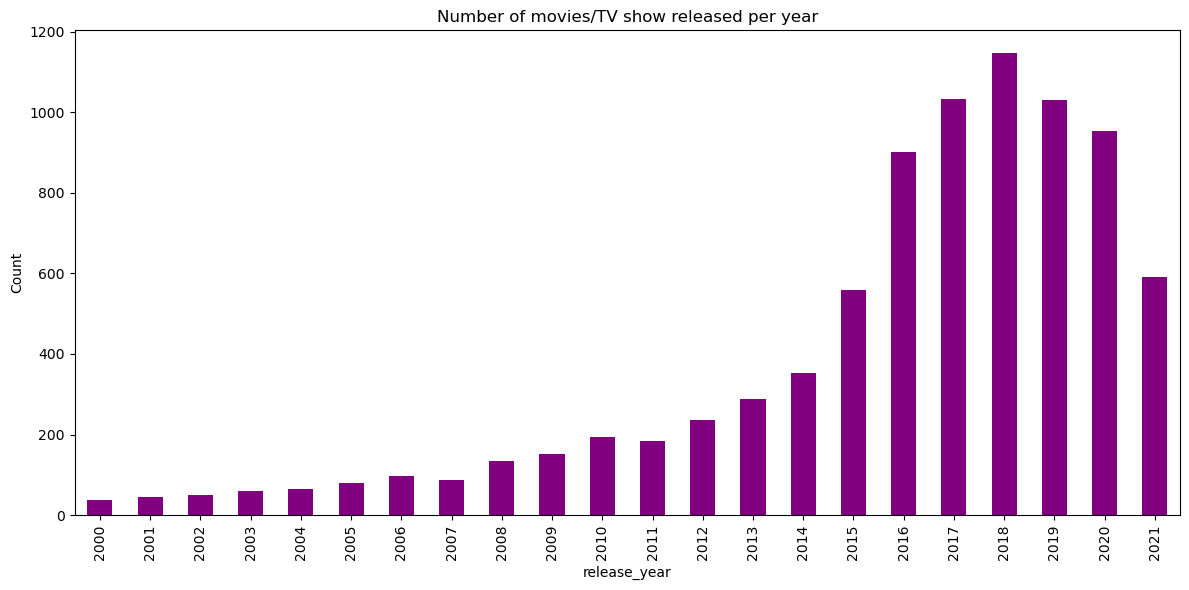

In [38]:
data9.plot(kind = "bar",figsize = (12,6),color = "purple")
plt.ylabel("Release year")
plt.ylabel("Count")
plt.title("Number of movies/TV show released per year")
plt.tight_layout()
plt.show()

Number of movies/TV shows released was increased with time. Maximum content was released in 2018 but we saw above that in 2019 maximum content was added on netflix. This shows that it takes generally 1 year for the content to be added on netflix after the official release.

(2018=1146 and 2017=1032)


In [39]:
data10 = df_genre['listed_in'].value_counts()[:20].sort_index()
data10

listed_in
Action & Adventure           859
Children & Family Movies     641
Comedies                    1674
Crime TV Shows               469
Documentaries                869
Docuseries                   394
Dramas                      2427
Horror Movies                357
Independent Movies           756
International Movies        2752
International TV Shows      1350
Kids' TV                     449
Music & Musicals             375
Reality TV                   255
Romantic Movies              616
Romantic TV Shows            370
Stand-Up Comedy              343
TV Comedies                  574
TV Dramas                    762
Thrillers                    577
Name: count, dtype: int64

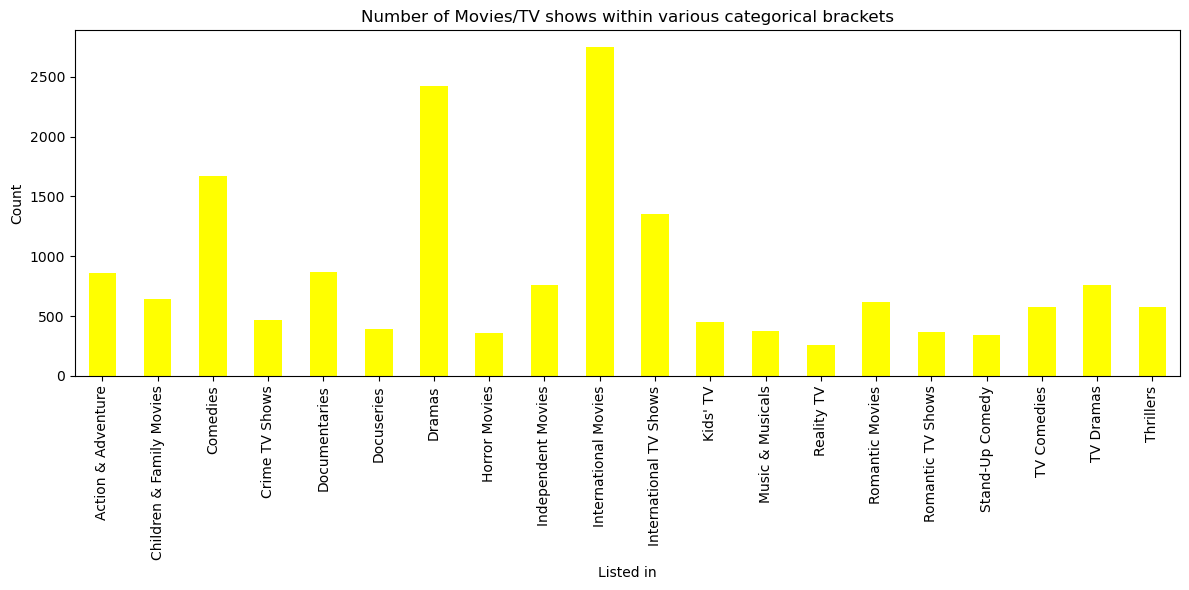

In [40]:
data10.plot(kind = "bar",figsize = (12,6),color = "yellow")
plt.xlabel("Listed in")
plt.ylabel("Count")
plt.title("Number of Movies/TV shows within various categorical brackets")
plt.tight_layout()
plt.show()

Maximum number of movies/TV shows added on netflix was listed in the category of international movies. This shows that people love to wacth movies which are released globally. Dramas and comedy categories are also present in the list holding significant number of movies/TV shows.
(International TV Shows=1350,
Dramas=2427 and
Comedies=1674)